# Phase 3: Imputation with Missing Modalities

This notebook evaluates the ability of the trained shared latent space model
to impute entire missing modalities at test time.

We consider two evaluation settings:
1. **Leave-one-modality-out imputation**, where exactly one modality is missing
2. **All possible missingness patterns**, covering arbitrary subsets of observed modalities

All evaluations are performed on the held-out test set using the shared model
trained in Phase 2.


## Setup

We import helper utilities for:
- Loading trained autoencoders and shared models
- Generating missing-modality scenarios
- Running imputation
- Evaluating reconstruction quality

All heavy lifting is performed by reusable functions in `src/`.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import random
from typing import Dict, List, Tuple
import pickle
from torch.optim import Adam
import matplotlib.pyplot as plt
import pandas as pd
import json

In [2]:
from src.data_utils import *
from src.mae_masked import *
from src.shared_finetune import *
from src.impute import *
from src.translation import *
from src.evaluation import *

In [52]:
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 18,
    "axes.titlesize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})


## 0.1 Data loading and shared splits

We load the full multi-omic dataset and reuse the same train/validation/test splits
used during training to ensure a fair evaluation.

Only test samples are used for imputation experiments.


In [3]:
with open('tcga_redo_mlomicZ.pkl', 'rb') as f:
    multi_omic_data = pickle.load(f)
    
print(multi_omic_data.keys())

common_samples, train_idx, val_idx, test_idx = load_shared_splits_from_json(
    multi_omic_data,
    json_path='splits.json'
)
print(f"Shared N={len(common_samples)} | train={len(train_idx)} | val={len(val_idx)}| test={len(test_idx)}")

dict_keys(['cnv', 'miRNA', 'rna', 'methylation'])
Shared N=8034 | train=6409 | val=798| test=800


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

## 0.2 Loading the trained shared-space model

We reconstruct the shared model architecture by:
1. Loading each modality-specific autoencoder from Phase 1
2. Extracting encoders and decoders
3. Rebuilding the shared latent space model
4. Loading trained weights from Phase 2


In [5]:
train_loader, val_loader, test_loader = make_loaders_from_splits(
    multi_omic_data, common_samples, train_idx, val_idx, test_idx, batch_size=64
)

In [6]:
# 1) Rebuild encoders/decoders/hidden_dims and mask_values
encoders, decoders, hidden_dims = {}, {}, {}
mask_values = {}

for mod in multi_omic_data.keys():
    ae_m, hidden_dim_m, cfg_m = load_modality_with_config(
        f"aes_redo_z/{mod}_ae.pt", map_location=device
    )
    ae_m = ae_m.to(device)

    enc, dec = extract_encoder_decoder_from_pretrained(ae_m)
    encoders[mod] = enc
    decoders[mod] = dec
    hidden_dims[mod] = hidden_dim_m

    # modality-specific sentinel (default 0.0 if missing)
    mask_values[mod] = cfg_m.get("mask_value", 0.0)

print("mask_values:", mask_values)

# 2) Load checkpoint into shared-space model
checkpoint_path = "checkpoints/fintuned/shared_model_ep200.pt"
model = load_shared_model(
    MultiModalWithSharedSpace,
    encoders,
    decoders,
    hidden_dims,
    shared_dim=256,
    proj_depth=1,
    checkpoint_path=checkpoint_path,
    map_location=device
)
model = model.to(device)
model.eval()


/net/noble/vol1/home/nambiar4/Documents/Final/src/mae_masked.py:742: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path, map_location=map_location)


mask_values: {'cnv': 0.0, 'miRNA': 0, 'rna': 0, 'methylation': 0.0}


/net/noble/vol1/home/nambiar4/Documents/Final/src/shared_finetune.py:204: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map

[Loaded] Shared model from checkpoints/fintuned/shared_model_ep200.pt


MultiModalWithSharedSpace(
  (encoders): ModuleDict(
    (cnv): ModalityEncoder(
      (net): Sequential(
        (0): Linear(in_features=3105, out_features=256, bias=True)
      )
    )
    (miRNA): ModalityEncoder(
      (net): Sequential(
        (0): Linear(in_features=383, out_features=128, bias=True)
      )
    )
    (rna): ModalityEncoder(
      (net): Sequential(
        (0): Linear(in_features=3007, out_features=512, bias=True)
      )
    )
    (methylation): ModalityEncoder(
      (net): Sequential(
        (0): Linear(in_features=3139, out_features=256, bias=True)
      )
    )
  )
  (decoders): ModuleDict(
    (cnv): ModalityDecoder(
      (net): Sequential(
        (0): Linear(in_features=256, out_features=3105, bias=True)
      )
    )
    (miRNA): ModalityDecoder(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=383, bias=True)
      )
    )
    (rna): ModalityDecoder(
      (net): Sequential(
        (0): Linear(in_features=512, out_features=

The printed summary above shows the full shared model architecture, including:
- Modality-specific encoders and decoders
- Projection heads into the shared latent space
- Reverse projections back to modality-specific latent spaces

Each modality uses a sentinel `mask_value` consistent with its Phase 1 training.
These values are used to represent missing inputs during imputation.


## 0.3 Leave-one-modality-out imputation

We first evaluate a controlled missingness scenario in which exactly one modality
is missing for each test sample.

For each modality:
- The remaining modalities are provided as input
- The missing modality is reconstructed via the shared latent space


In [11]:
multi_ds = MultiOmicDataset({m: df for m, df in multi_omic_data.items()})
test_samples = [multi_ds.common_samples[i] for i in test_idx]

In [12]:
pred_dict = leave_one_out_imputation(
    model=model,
    mask_values=mask_values,
    multi_omic_data=multi_omic_data,
    common_samples=test_samples,
    batch_size=64,
    device=device,
    scenarios_dir="scenarios_leave_one_out_test",              # each scenario = data without one modality
    save_pred_pickle_path="imputations_leave_one_out_test.pkl" # predictions dictionary
)


[Saved scenario] scenarios_leave_one_out_test/scenario_present_methylation_miRNA_rna_missing_cnv.pkl
[Saved scenario] scenarios_leave_one_out_test/scenario_present_cnv_methylation_rna_missing_miRNA.pkl
[Saved scenario] scenarios_leave_one_out_test/scenario_present_cnv_methylation_miRNA_missing_rna.pkl
[Saved scenario] scenarios_leave_one_out_test/scenario_present_cnv_miRNA_rna_missing_methylation.pkl
[Saved predictions] imputations_leave_one_out_test.pkl


Predictions and missingness scenarios are saved to disk for reproducibility and reuse in downstream analyses.
Each scenario corresponds to one held-out modality.


In [5]:
with open("imputations_leave_one_out_test.pkl", 'rb') as f:
    pred_dict = pickle.load(f)

## Reconstruction performance

We compare imputed values against ground truth using:
- Mean squared error (MSE)
- Pearson correlation (r)
- Spearman correlation (ρ)

Scatter plots show global agreement between imputed and true values across
all samples and features.


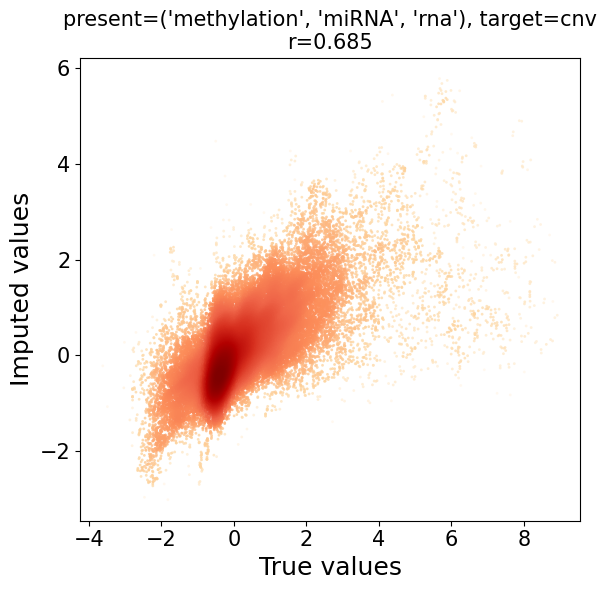

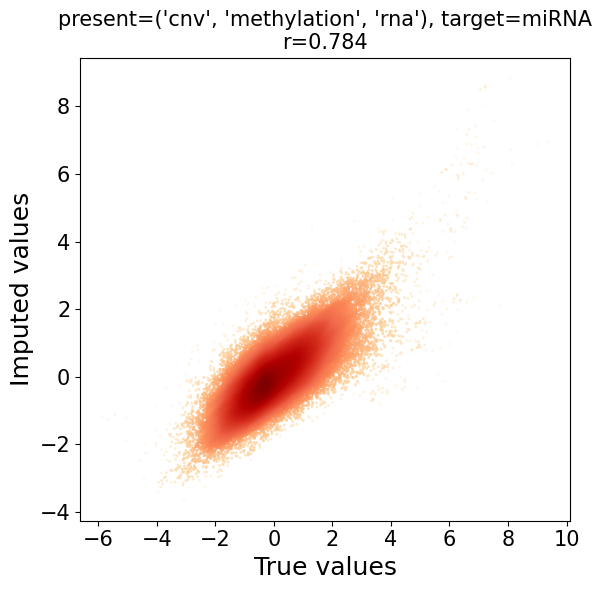

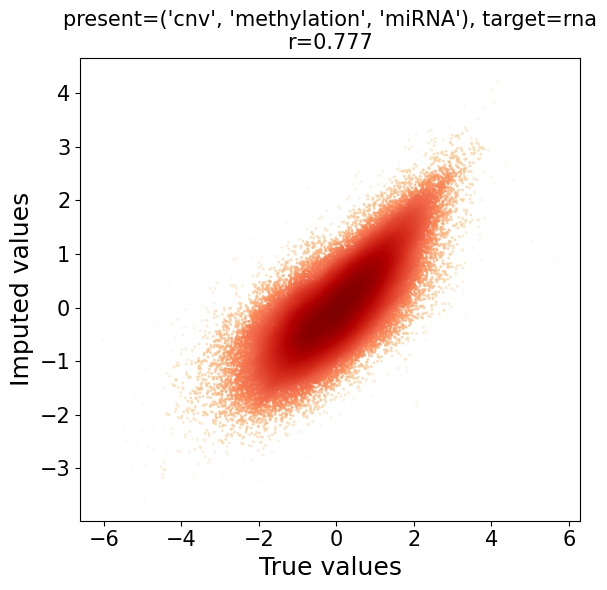

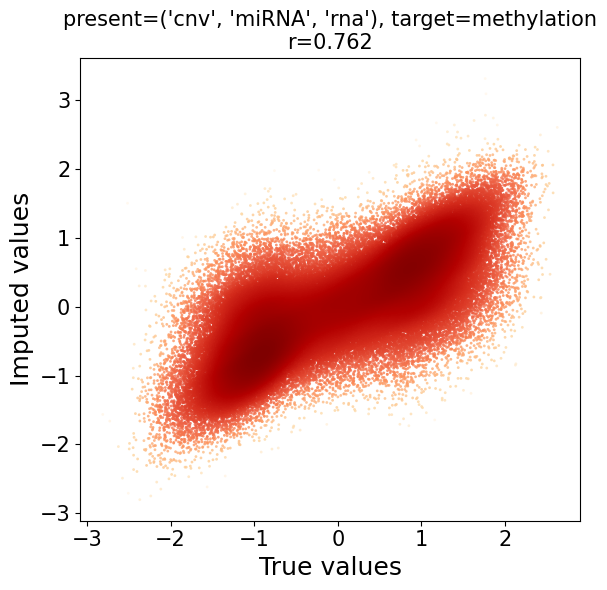

In [6]:
metrics = evaluate_imputations(pred_dict, multi_omic_data, plot_scatter=True, max_points_plot=100000)

The metrics dictionary below summarizes reconstruction quality for each
held-out modality.


In [7]:
metrics

{(('methylation', 'miRNA', 'rna'), 'cnv'): {'mse': 0.5276989869889993,
  'pearson': 0.6851230388225801,
  'spearman': 0.6446856521820352,
  'n_points': 2484000},
 (('cnv', 'methylation', 'rna'), 'miRNA'): {'mse': 0.38340618270373134,
  'pearson': 0.784295043635984,
  'spearman': 0.7503793225329748,
  'n_points': 306400},
 (('cnv', 'methylation', 'miRNA'), 'rna'): {'mse': 0.4005276087507527,
  'pearson': 0.777153734112711,
  'spearman': 0.7665374074235631,
  'n_points': 2405600},
 (('cnv', 'miRNA', 'rna'), 'methylation'): {'mse': 0.4234447390830107,
  'pearson': 0.7622943970716195,
  'spearman': 0.7624423562591789,
  'n_points': 2508098}}

## 0.4 Imputation under arbitrary missingness patterns

Beyond leave-one-out scenarios, we evaluate the model under all possible
combinations of available modalities.

This setting reflects real-world data, where multiple modalities may be
simultaneously missing.


In [35]:
DISPLAY_NAME = {
    "rna": "mRNA",
}

In [7]:
multi_ds = MultiOmicDataset({m: df for m, df in multi_omic_data.items()})
test_samples = [multi_ds.common_samples[i] for i in test_idx]

In [8]:
pred_dict = all_possible_imputation(
    model=model,
    mask_values=mask_values,
    multi_omic_data=multi_omic_data,
    common_samples=test_samples,
    batch_size=64,
    device=device,
    scenarios_dir="scenarios_all_possible_test",              # each scenario = one possible combination of missingness
    save_pred_pickle_path="imputations_all_possible_test.pkl" # predictions dictionary
)

[Saved scenario] scenarios_all_possible_test/scenario_present_methylation_miRNA_rna_missing_cnv.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_methylation_rna_missing_cnv_miRNA.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_methylation_miRNA_missing_cnv_rna.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_miRNA_rna_missing_cnv_methylation.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_methylation_missing_cnv_miRNA_rna.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_rna_missing_cnv_methylation_miRNA.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_miRNA_missing_cnv_methylation_rna.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_cnv_methylation_rna_missing_miRNA.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_methylation_rna_missing_cnv_miRNA.pkl
[Saved scenario] scenarios_all_possible_test/scenario_present_cnv_methylation_missing_miRNA_rna.pkl


Each scenario corresponds to a unique subset of available modalities.
Predictions are saved to disk for reproducibility.


In [9]:
metrics = evaluate_imputations(pred_dict, multi_omic_data, plot_scatter=False)

## Visualizing imputation performance across missingness patterns

To summarize performance across many missingness scenarios, we construct
UpSet-style plots that show:
- Imputation performance for a target modality
- Which modalities were available as input
- How performance changes with the number and identity of observed modalities


In [14]:
def metrics_to_upset_df(metrics, score_key="pearson"):
    """
    Convert metrics dict into a tidy DataFrame suitable for UpSet-style plots.
    """
    rows = []
    for (present_mods, target_mod), vals in metrics.items():
        rows.append({
            "target": target_mod,
            "present": set(present_mods),
            "n_present": len(present_mods),
            "score": vals[score_key],
        })
    return pd.DataFrame(rows)

df_upset = metrics_to_upset_df(metrics)

In [47]:
def plot_upset_for_target(
    df,
    target,
    all_modalities,
    score_label="Correlation r",
):
    """
    UpSet-style plot for imputing one target modality.
    """
    sub = df[df["target"] == target].copy()

    # Sort: more available modalities first, then by score
    sub = sub.sort_values(
        by='score',
        ascending=False
    ).reset_index(drop=True)

    n = len(sub)
    mods = [m for m in all_modalities if m != target]

    fig = plt.figure(figsize=(max(6, n * 0.6), 6))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)

    # ---- Top bar plot ----
    ax_bar = fig.add_subplot(gs[0])
    bars = ax_bar.bar(range(n), sub["score"],color="tab:orange")
    ymax = sub["score"].max()
    ax_bar.set_ylim(0, ymax * 1.1)

    ax_bar.set_ylabel(score_label)
    display_target = DISPLAY_NAME.get(target, target)
    ax_bar.set_title(
    f"Imputing {display_target}")

    for i, k in enumerate(sub["n_present"]):
        ax_bar.text(i, sub["score"].iloc[i] + 0.01, str(k),
                    ha="center", va="bottom", fontsize=9)

    ax_bar.set_xticks([])

    # ---- Dot matrix ----
    ax_mat = fig.add_subplot(gs[1], sharex=ax_bar)

    for i, present in enumerate(sub["present"]):
        for j, mod in enumerate(mods):
            filled = mod in present
            ax_mat.scatter(
                i, j,
                s=50,
                color="black" if filled else "white",
                edgecolor="black",
                zorder=3
            )

    ax_mat.set_yticks(range(len(mods)))
    ax_mat.set_yticklabels([DISPLAY_NAME.get(m, m) for m in mods])
    ax_mat.set_xlabel("Available modalities")

    ax_mat.set_xlim(-0.5, n - 0.5)
    ax_mat.set_ylim(-0.5, len(mods) - 0.5)

    for spine in ["top", "right", "left"]:
        ax_mat.spines[spine].set_visible(False)

    plt.show()


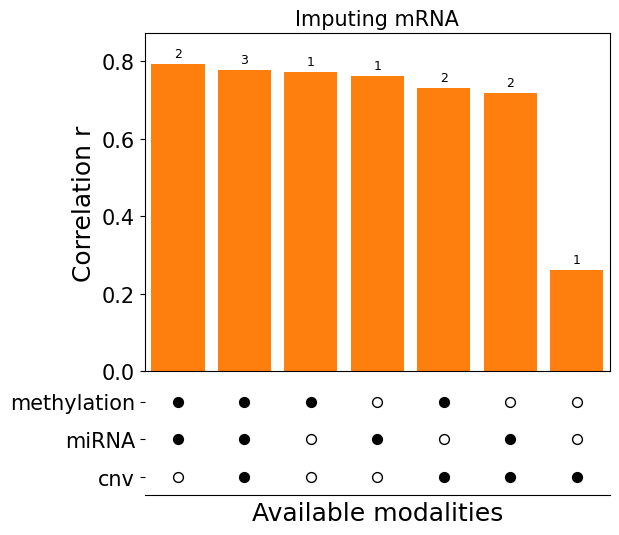

In [53]:
all_modalities = list(multi_omic_data.keys())

plot_upset_for_target(
    df_upset,
    target="rna",
    all_modalities=all_modalities,
)

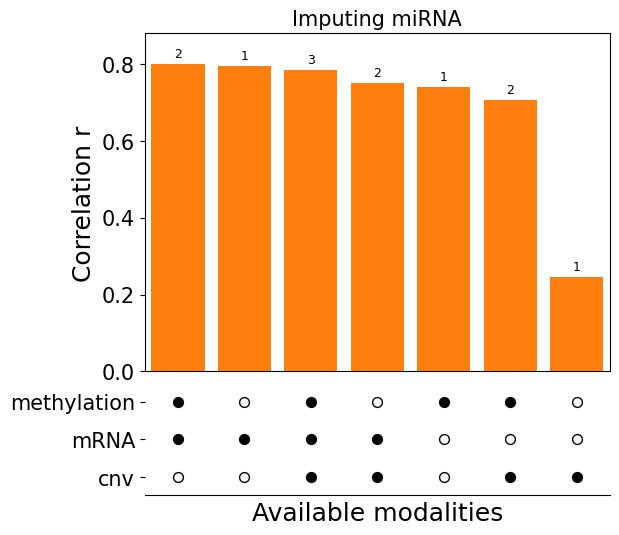

In [54]:
plot_upset_for_target(
    df_upset,
    target="miRNA",
    all_modalities=all_modalities,
)

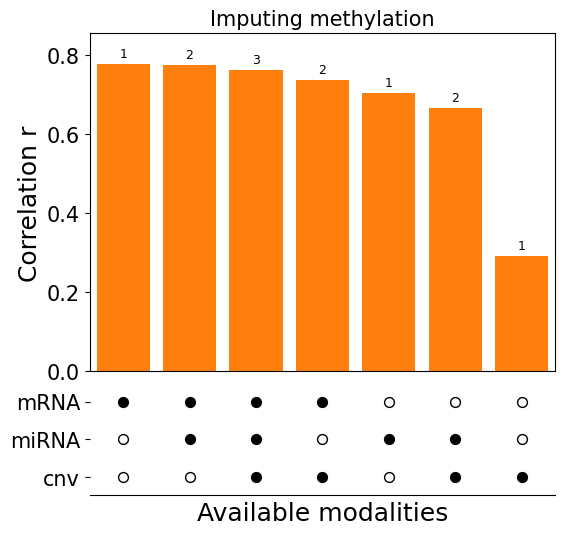

In [55]:
plot_upset_for_target(
    df_upset,
    target="methylation",
    all_modalities=all_modalities,
)

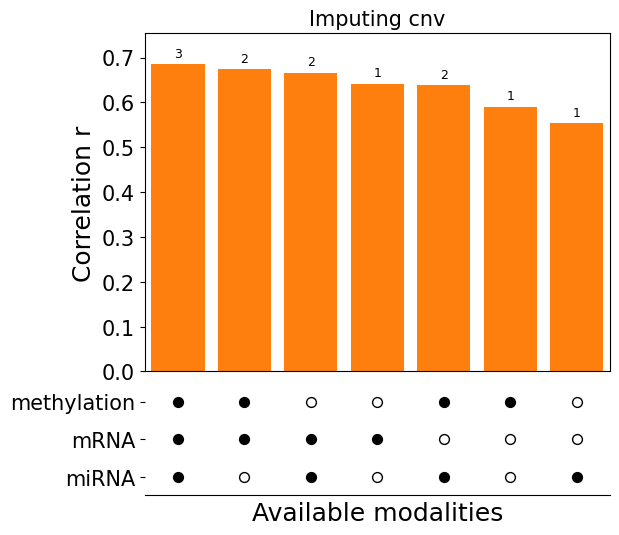

In [56]:
plot_upset_for_target(
    df_upset,
    target="cnv",
    all_modalities=all_modalities,
)

## Summary

This notebook evaluated the shared latent space model under realistic
missing-modality scenarios.

Across both controlled leave-one-out experiments and arbitrary missingness
patterns, the model consistently reconstructs missing modalities with high
correlation, demonstrating effective cross-modal integration.
